Libraries to read and split data & measure accuracy

In [2]:
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [8]:
from google.colab import files
files.upload()


Saving mammographic.dat to mammographic.dat


{'mammographic.dat': b'@relation mammographic\n@attribute BI-RADS integer [0,6]\n@attribute Age integer [18,96]\n@attribute Shape integer [1,4]\n@attribute Margin integer [1,5]\n@attribute Density integer [1,4]\n@attribute Severity {0, 1}\n@inputs BI-RADS, Age, Shape, Margin, Density\n@outputs Severity\n@data\n5,67,3,5,3,1\n4,43,1,1,?,1\n5,58,4,5,3,1\n4,28,1,1,3,0\n5,74,1,5,?,1\n4,65,1,?,3,0\n4,70,?,?,3,0\n5,42,1,?,3,0\n5,57,1,5,3,1\n5,60,?,5,1,1\n5,76,1,4,3,1\n3,42,2,1,3,1\n4,64,1,?,3,0\n4,36,3,1,2,0\n4,60,2,1,2,0\n4,54,1,1,3,0\n3,52,3,4,3,0\n4,59,2,1,3,1\n4,54,1,1,3,1\n4,40,1,?,?,0\n?,66,?,?,1,1\n5,56,4,3,1,1\n4,43,1,?,?,0\n5,42,4,4,3,1\n4,59,2,4,3,1\n5,75,4,5,3,1\n2,66,1,1,?,0\n5,63,3,?,3,0\n5,45,4,5,3,1\n5,55,4,4,3,0\n4,46,1,5,2,0\n5,54,4,4,3,1\n5,57,4,4,3,1\n4,39,1,1,2,0\n4,81,1,1,3,0\n4,77,3,?,?,0\n4,60,2,1,3,0\n5,67,3,4,2,1\n4,48,4,5,?,1\n4,55,3,4,2,0\n4,59,2,1,?,0\n4,78,1,1,1,0\n4,50,1,1,3,0\n4,61,2,1,?,0\n5,62,3,5,2,1\n5,44,2,4,?,1\n5,64,4,5,3,1\n4,23,1,1,?,0\n2,42,?,?,4,0\n5,

Read the Dataset


In [10]:
data = pd.read_csv("mammographic.dat", comment='@', header=None)

data.columns = [
    "BI-RADS", "Age", "Shape", "Margin", "Density", "Severity"
]

data.head()

,BI-RADS,Age,Shape,Margin,Density,Severity
0,5,67,3,5,3,1
1,4,43,1,1,?,1
2,5,58,4,5,3,1
3,4,28,1,1,3,0
4,5,74,1,5,?,1


961 rows(mammogram record), 6 columns

In [11]:
data.shape


(961, 6)

Replace missing values(131 data)

In [12]:
data.replace("?", np.nan, inplace=True)
data = data.astype(float)
data.fillna(data.mean(), inplace=True)


Split input and output

In [13]:
X = data[["BI-RADS", "Age", "Shape", "Margin", "Density"]]
y = data["Severity"]


Normalize data

In [14]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)


Split dataset(70/30)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


1. Evolutionary ALgorithm(GA)

In [16]:
def ga_fitness(weights):
    linear_output = np.dot(X_train, weights)
    predictions = (linear_output > 0.5).astype(int)
    return accuracy_score(y_train, predictions)

In [17]:
POP_SIZE = 20
N_GEN = 50
N_FEATURES = X_train.shape[1]
MUT_RATE = 0.1

In [18]:
population = [np.random.rand(N_FEATURES) for _ in range(POP_SIZE)]

In [19]:
for gen in range(N_GEN):
    new_population = []

    for _ in range(POP_SIZE):
        parent1, parent2 = random.sample(population, 2)

        # Single-point crossover
        cp = random.randint(1, N_FEATURES - 1)
        child = np.concatenate([parent1[:cp], parent2[cp:]])

        # Mutation
        for i in range(N_FEATURES):
            if random.random() < MUT_RATE:
                child[i] = random.random()

        new_population.append(child)

    population = new_population

In [20]:
best_weights = max(population, key=ga_fitness)

Testing Evolutionary Algorithm

In [22]:
test_preds = (np.dot(X_test, best_weights) > 0.5).astype(int)

ga_results = {
    "Accuracy": accuracy_score(y_test, test_preds),
    "Precision": precision_score(y_test, test_preds),
    "Recall": recall_score(y_test, test_preds),
    "F1": f1_score(y_test, test_preds)
}

ga_results


{'Accuracy': 0.7750865051903114,
 'Precision': 0.6914285714285714,
 'Recall': 0.9166666666666666,
 'F1': 0.7882736156351792}

Confusion Matrix

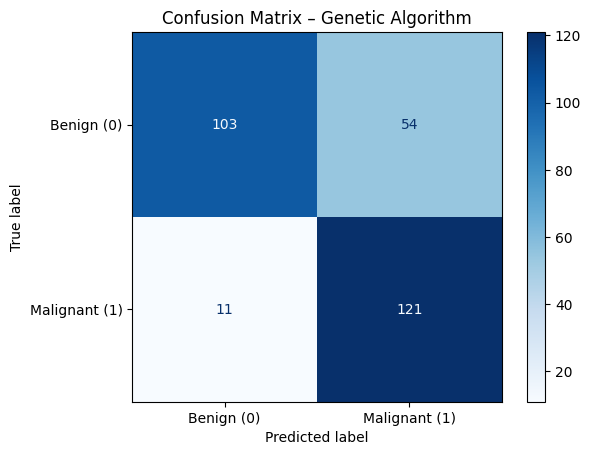

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Confusion Matrix for GA
cm_ga = confusion_matrix(y_test, test_preds)

disp_ga = ConfusionMatrixDisplay(
    confusion_matrix=cm_ga,
    display_labels=["Benign (0)", "Malignant (1)"]
)

disp_ga.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Genetic Algorithm")
plt.show()


2. Hybrid Algorithm(GA + Fuzzy)

In [25]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.1 MB/s eta 0:00:00


In [26]:
import skfuzzy as fuzz


In [64]:
def triangular_mf(x, a, b, c):
    return np.maximum(
        np.minimum((x - a) / (b - a + 1e-6), (c - x) / (c - b + 1e-6)),
        0
    )


In [65]:
def hybrid_fitness(params):
    a, b, c = params

    # Enforce valid fuzzy triangle
    if not (0 <= a < b < c <= 1):
        return 0

    # Use BI-RADS feature only (index 0)
    bi_rads = X_train[:, 0]

    # Fuzzy membership
    membership = triangular_mf(bi_rads, a, b, c)

    # Decision rule
    predictions = (membership > 0.5).astype(int)

    # Optimize balanced performance
    return f1_score(y_train, predictions, zero_division=0)


In [66]:
# GA parameters
POP_SIZE = 20
N_GEN = 40
MUT_RATE = 0.2

# Each chromosome = [a, b, c]
population = [np.sort(np.random.rand(3)) for _ in range(POP_SIZE)]

# GA loop
for gen in range(N_GEN):
    new_population = []

    for _ in range(POP_SIZE):
        parent = random.choice(population)
        child = parent.copy()

        # Mutation
        for i in range(3):
            if random.random() < MUT_RATE:
                child[i] += np.random.normal(0, 0.1)

        # Keep values in [0,1] and sorted
        child = np.clip(child, 0, 1)
        child = np.sort(child)

        new_population.append(child)

    population = new_population

# Best fuzzy parameters
best_params = max(population, key=hybrid_fitness)


Testing Hybrid algorithm

In [67]:
a, b, c = best_params

bi_rads_test = X_test[:, 0]
membership_test = triangular_mf(bi_rads_test, a, b, c)
hybrid_preds = (membership_test > 0.5).astype(int)

hybrid_results = {
    "Accuracy": accuracy_score(y_test, hybrid_preds),
    "Precision": precision_score(y_test, hybrid_preds, zero_division=0),
    "Recall": recall_score(y_test, hybrid_preds, zero_division=0),
    "F1": f1_score(y_test, hybrid_preds, zero_division=0)
}


hybrid_results


{'Accuracy': 0.8166089965397924,
 'Precision': 0.8691588785046729,
 'Recall': 0.7045454545454546,
 'F1': 0.7782426778242678}

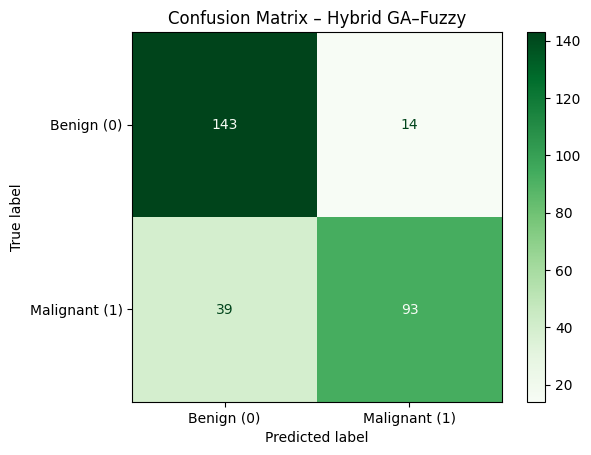

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Confusion Matrix for Hybrid GA–Fuzzy
cm_hybrid = confusion_matrix(y_test, hybrid_preds)

disp_hybrid = ConfusionMatrixDisplay(
    confusion_matrix=cm_hybrid,
    display_labels=["Benign (0)", "Malignant (1)"]
)

disp_hybrid.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix – Hybrid GA–Fuzzy")
plt.show()


Comparison Graph

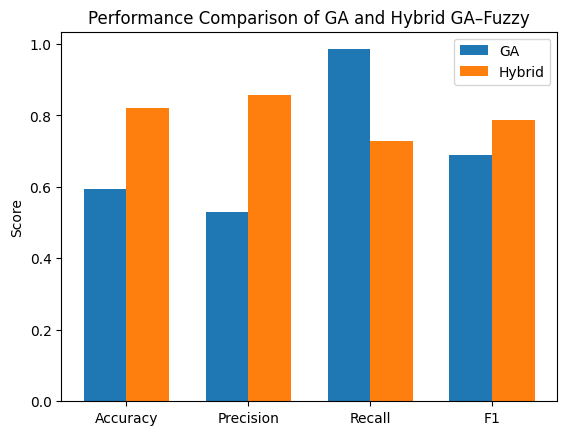

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]
ga_values = [ga_results[m] for m in metrics]
hybrid_values = [hybrid_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure()
plt.bar(x - width/2, ga_values, width, label='GA')
plt.bar(x + width/2, hybrid_values, width, label='Hybrid')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison of GA and Hybrid GA–Fuzzy")
plt.legend()
plt.show()
